In [33]:
# моделирование случайных блужданий
# в ограниченной с обеих сторон
# одномерной области

In [34]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение генератора случайных чисел
import random

# подключение пакета matplotlib.pyplot
import matplotlib.pyplot as plt


In [ ]:
# Ячейка № 2

# задание функции, возвращающей
# ансамбль значений координат
# броуновской частицы
def Walk_LAD(x0, X_min, X_max, Step, N_step, N_trial, p):
    # x0 - координата начальной точки
    #      броуновской частицы
    # X_min - левая граница одномерной
    #         области рассеяния
    # X_mах - правая граница одномерной
    #         области рассеяния
    # Step - значение шага метода Монте-Карло
    # N_Step - число шагов броуновской частицы
    # N_trial - число незавсимых испытаний
    #           в методе Монте-Карло
    # p - вероятность перехода на данном шаге
    #     броуновской частицы вправо

    # инициализация массива, используемого
    # для хранения ансамбля координат
    # броуновской частицы
    z = np.zeros(N_trial + 1)

    # сохранение в нулевом элементе массива z
    # начальной координаты броуновской частицы
    z[0] = x0

    # реализация метода Монте-Карло
    for i in range(1, N_trial + 1):
        x = x0
        for j in range(N_step):
            # вычисление новой координаты
            # броуновской частицы
            if p >= random.uniform(0, 1):
                x = x + Step
                if x > X_max:
                    # если новая координата больше X_max,
                    # вычисление значения координаты
                    # броуновской частицы после
                    # отражения от правой границы
                    x = 2 * X_max - x
            else:
                x = x - Step
                if x < X_min:
                    # если новая координата меньше X_min,
                    # вычисление значения координаты
                    # броуновской частицы после
                    # отражения от левой границы
                    x = 2 * X_min - x
        z[i] = x

    return z

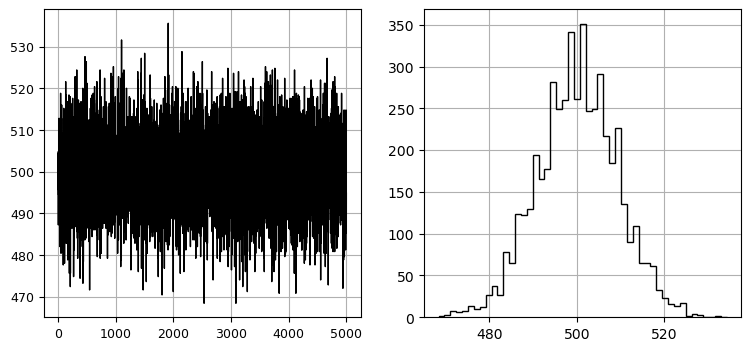

In [36]:
# Ячейка № 3

# инициализация генератора случайных чисел
random.seed()

# задания количества шагов броуновской частицы
N_step = 2 * 10**3

# задание числа независимых испытаний
# метода Монте-Карло
N_trial = 5 * 10**3

# задание вероятности перехода на данном шаге
# броуновской частицы вправо
p = 0.5

# задание начальной координаты
# броуновской частицы
x0 = 500

# задание границ одномерной области
# рассеяния
X_min = 0
X_max = 1000

# задание длины шага
# броуновской частицы
Step = 0.2

# значений ансамбля координат броуновской частицы
M = Walk_LAD(x0, X_min, X_max, Step, N_step, N_trial, p)

# визуализация ансамбля координат
# броуновской частицы и его
# эмпирической плотности распределения

fig = plt.figure(figsize=(9, 4))

# визуализация ансамбля координат
# броуновской частицы
plt.subplot(1, 2, 1)
plt.plot(M, color="black", linewidth=1)
# plt.ylim([0,0.05])
plt.grid(True)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

# визуализация эмпирической
# плотности распределения
# ансамбля координат
# броуновской частицы
plt.subplot(1, 2, 2)

# задание значений интервалов гистограммы
N_bin = 50
xbins = np.arange(np.min(M), np.max(M), (max(M) - min(M)) / N_bin)
plt.hist(M, bins=xbins, histtype="step", color="black", density=False)
plt.grid(True)

plt.show()

In [ ]:
# Ячейка № 4

# задание функции, возвращающей
# значения усредненных по ансамблям
# зависимостей координат
# и среднеквадратического отклонения
# броуновской частицы, совершающей блуждания в
# в ограниченной с двух сторон и неограниченной
# областях рассеяния
def Walk_left_rigth(x0, X_min, X_max, Step, N_step, N_trial, p):
    # x0 - начальная координата
    #      броуновской частицы
    # X_max - координата отражающей стенки
    # Step - значениe шага метода Монте-Карло
    # N_Step - длина единичной реализации
    #          метода Монте-Карло
    # N_trial - число независимых испытаний
    #           метода Монте-Карло
    # p - пороговая вероятность

    # инициализация массивов, используемых для хранения
    # ансамблей траекториий броуновских частиц,
    # движущихся в ограниченной справа (X_R) и
    # неограниченной областях (X_N)
    X_LAD = np.zeros([N_step, N_trial + 1])
    X_N = np.zeros([N_step, N_trial + 1])

    # размещение координат начальных точек
    # траекторий броуновских частиц
    # в массивах X_R, X_N
    X_LAD[:, 0] = x0
    X_N[:, 0] = x0

    # вычисление ансамблей траекторий
    # броуновских частиц, движущихся
    # в ограниченной c двух сторон (X_LAD) и
    # неограниченной областях (X_N)
    # в соответствие с методом Монте-Карло
    for i in range(1, N_trial + 1):
        x_LAD = x0
        x_N = x0
        for j in range(N_step):
            if p < random.uniform(0, 1):
                x_LAD = x_LAD + Step
                x_N = x_N + Step
                if x_LAD > X_max:
                    # если новая координата больше X_max,
                    # вычисление значения координаты
                    # броуновской частицы после
                    # отражения от правой границы
                    x_LAD = 2 * X_max - x_LAD
            else:
                x_LAD = x_LAD - Step
                x_N = x_N - Step
                if x_LAD < X_min:
                    # если новая координата меньше X_min,
                    # вычисление значения координаты
                    # броуновской частицы после
                    # отражения от левой границы
                    x_LAD = 2 * X_min - x_LAD
            X_LAD[j, i] = x_LAD
            X_N[j, i] = x_N

    # инициализация массивов,
    # используемых для хранения
    # мгновенных усредненных по ансамблям
    # независимых реализаций
    # значений координат и среднеквадратических отклонений
    # броуновских частиц
    d_LAD = np.zeros(N_step)
    d_N = np.zeros(N_step)
    m_LAD = np.zeros(N_step)
    m_N = np.zeros(N_step)

    # вычисление мгновенных
    # усредненных по ансамблям
    # независимых реализаций
    # значений координат и
    # среднеквадратических отклонений
    # броуновских частиц
    for i in range(N_step):
        # вычисление средних
        # по ансамблю траекторий
        # мгновенных значений координат
        # броуновской частицы, совершающей
        # движение в области, ограниченной справа
        m_LAD[i] = np.mean(X_LAD[i, :])

        # вычисление средних
        # по ансамблю траекторий
        # мгновенных значениий координат
        # броуновской частицы, совершающей
        # движение в неограниченной области
        m_N[i] = np.mean(X_N[i, :])

        # вычисление мгновенных значений
        # среднеквадратического отклонения
        # значений координат ансамбля траекторий
        # броуновской частицы, совершающей
        # движение в области, ограниченной справа
        d_LAD[i] = np.var(X_LAD[i, :] - m_LAD[i])

        # вычисление мгновенных значений
        # среднеквадратического отклонения
        # мгновенных значений средней
        # по ансамблю реализаций
        # зависимости координат
        # от номера шага
        d_N[i] = np.var(X_N[i, :] - m_N[i])

    return m_LAD, m_N, d_LAD, d_N


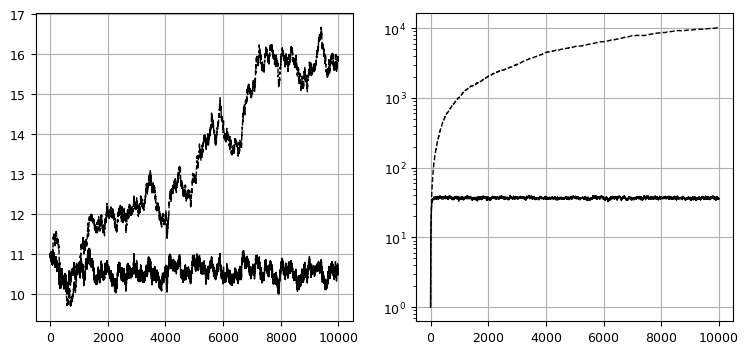

In [ ]:
# Ячейка # 5

# вычисление и визуализация
# усредненных по ансамблям реализаций
# зависимостей мгновенных координат
# броуновских частиц, совершающих блуждания
# в ограниченной с двух сторон и
# неограниченнной областях рассеяния
# и их среднеквадратического отклонения
# от номера шага

# задание координаты начальной точки
# траектории броуновской частицы
x0 = 11

# задание значения координаты
# левой границы области рассеяния
X_min = 0

# задание значения координаты
# правой границы области рассеяния
X_max = 21

# задание значения шага
# броуновской частицы
Step = 1

# задание числа шагов
# броуновской частицы
N_step = 10**4

# задание числа
# независимых испытаний
# в методе Монте-Карло
N_trial = 1 * 10**3

# задание порогового
# значения вероятности
p = 0.5

# вычисление мгновенных
# усредненных по ансамблям
# независимых реализаций
# значений зависимостей координат и
# среднеквадратических отклонений
# броуновских частиц от номера шага
[mL, mN, dL, dN] = Walk_left_rigth(x0, X_min, X_max, Step, N_step, N_trial, p)

# визуализация зависимостей
# мгновенных усредненных по ансамблям
# независимых реализаций
# значений координат и
# среднеквадратических отклонений
# броуновских частиц от номера
fig = plt.figure(figsize=(9, 4))

# визуализация усредненной по ансамблям
# независимых реализаций реализации
# зависимости мгновенных значений координат
# от номера шага броуновской частицы
plt.subplot(1, 2, 1)
plt.plot(mL, color="black", linewidth=1)
plt.plot(mN, "--", color="black", linewidth=1)
# plt.ylim([0,0.05])
plt.grid(True)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

# визуализация усредненной по ансамблям
# независимых реализаций реализации
# зависимости мгновенных значений
# среднеквадартического отклонения
# координат броуновской частицы
# от номера шага
plt.subplot(1, 2, 2)
plt.semilogy(dL, color="black", linewidth=1)
plt.semilogy(dN, "--", color="black", linewidth=1)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.grid(True)

plt.show()

In [ ]:
# Ячейка № 6

# задание функции, возвращающей
# значения усредненных по ансамблям
# зависимостей координат
# и среднеквадратического отклонения
# броуновской частицы, совершающей блуждания в
# в ограниченной с двух сторон области рассеяния
def Walk_left_rigth2(x0, X_min, X_max, Step, N_step, N_trial, p):
    # x0 - начальная координата
    #      броуновской частицы
    # X_max - координата отражающей стенки
    # Step - значение шага метода Монте-Карло
    # N_Step - длина единичной реализации
    #          метода Монте-Карло
    # N_trial - число независимых испытаний
    #           метода Монте-Карло
    # p - пороговая вероятность

    # инициализация массива, используемого
    # для хранения ансамблей
    # траекторий броуновских частиц
    X_LAD = np.zeros([N_step, N_trial + 1])

    # размещение координат начальных точек
    # траекторий броуновских частиц
    # в массивe X_LAD
    X_LAD[:, 0] = x0

    # вычисление ансамблей траекторий
    # броуновских частиц, движущихся
    # в ограниченной c двух сторон (X_LAD)
    # в соответствие с методом Монте-Карло
    for i in range(1, N_trial + 1):
        x_LAD = x0
        for j in range(N_step):
            if p < random.uniform(0, 1):
                x_LAD = x_LAD + Step
                if x_LAD > X_max:
                    # если новая координата больше X_max,
                    # вычисление значения координаты
                    # броуновской частицы после
                    # отражения от правой границы
                    x_LAD = 2 * X_max - x_LAD
            else:
                x_LAD = x_LAD - Step
                if x_LAD < X_min:
                    # если новая координата меньше X_min,
                    # вычисление значения координаты
                    # броуновской частицы после
                    # отражения от левой границы
                    x_LAD = 2 * X_min - x_LAD
            X_LAD[j, i] = x_LAD

    # инициализация массивов,
    # используемых для хранения
    # мгновенных усредненных по ансамблям
    # независимых реализаций зависимостей
    # значений координат и среднеквадратических отклонений
    # броуновских частиц от номера шага
    m_LAD = np.zeros(N_step)
    d_LAD = np.zeros(N_step)

    # вычисление мгновенных
    # усредненных по ансамблям
    # независимых реализаций
    # зависимостей значений координат и
    # среднеквадратических отклонений
    # броуновских частиц от номера шага
    for i in range(N_step):
        # вычисление средней
        # по ансамблю траекторий
        # зависимости координат
        # броуновской частицы от номера шага
        m_LAD[i] = np.mean(X_LAD[i, :])

        # вычисление значений средней
        # по ансамблю траекторий зависимости
        # среднеквадратического отклонения
        # координат броуновской частицы
        #  от номера шага
        d_LAD[i] = np.var(X_LAD[i, :] - m_LAD[i])

    return m_LAD, d_LAD

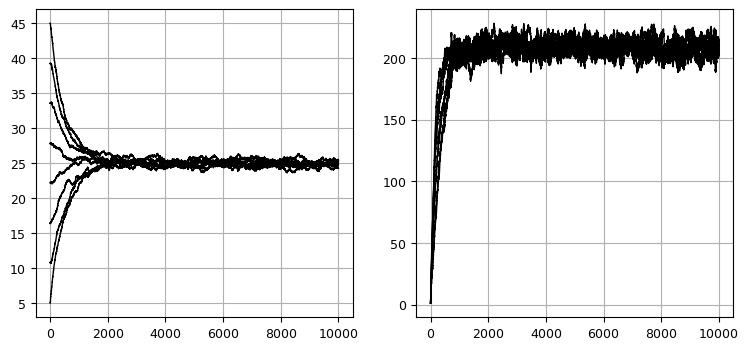

In [ ]:
# Ячейка № 7

# вычисление мгновенных
# усредненных по ансамблям
# независимых реализаций
# значений зависимостей координат  и
# среднеквадратических отклонений
# броуновских частиц от номера шага
# задание границ области рассеяния
# для выбранных значений x0

# задание значения координаты
# левой границы области рассеяния
X_min = 0

# задание значения координаты
# правой границы области рассеяния
X_max = 50

# задание значения шага
# броуновской частицы
Step = 1

# задание числа шагов
# броуновской частицы
N_step = 10**4

# задание числа
# независимых испытаний
# в методе Монте-Карло
N_trial = 1 * 10**3

# задание порогового
# значения вероятности
p = 0.5

# задание значений начальных
# координат броуновской частицы
x0 = np.linspace(5, 45, 8)

# инициализация массивов,
# используемых для хранения
# мгновенных усредненных по ансамблям
# независимых реализаций зависимостей
# значений координат и среднеквадратических отклонений
# броуновских частиц от номера шага
dL = np.zeros([N_step, len(x0)])
mL = np.zeros([N_step, len(x0)])

# вычисление мгновенных
# усредненных по ансамблям
# независимых реализаций
# значений зависимостей координат  и
# среднеквадратических отклонений
# броуновских частиц от номера шага
# для каждого значения начальной точки траектории
for i in range(len(x0)):
    [mL[:, i], dL[:, i]] = Walk_left_rigth2(
        x0[i], X_min, X_max, Step, N_step, N_trial, p
    )

# визуализация зависимостей
# мгновенных усредненных по ансамблям
# независимых реализаций
# значений координат и
# среднеквадратических отклонений
# броуновских частиц от времени
fig = plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
# визуализация зависимостей
# мгновенных усредненных по ансамблям
# независимых реализаций
# значений координат от номера шага

for i in range(len(x0)):
    plt.plot(mL[:, i], color="black", linewidth=1)

plt.grid(True)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

plt.subplot(1, 2, 2)
# визуализация зависимостей
# среднеквадратических отклонений
# броуновских частиц от номера шага
for i in range(len(x0)):
    plt.plot(dL[:, i], color="black", linewidth=1)

plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.grid(True)

plt.show()

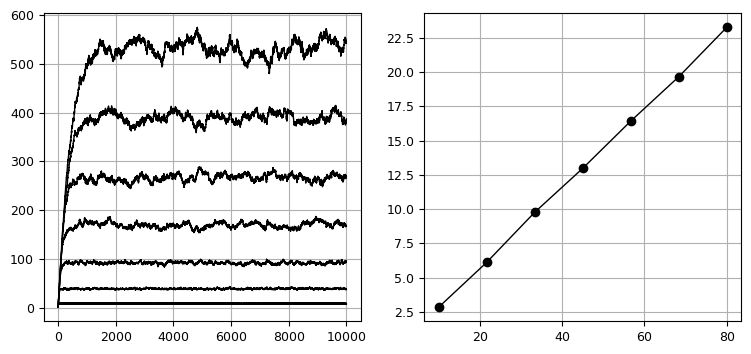

In [ ]:
# Ячейка № 8

# вычисление мгновенных
# усредненных по ансамблям
# независимых реализаций
# значений среднеквадратических
# отклонений координат броуновских частиц
# от номера шага для выбранных значений
#  размера области рассеяния

# задание значения координаты
# левой границы области рассеяния
X_min = 0

# задание значения шага
# броуновской частицы
Step = 1

# задание числа шагов
# броуновской частицы
N_step = 10**4

# задание числа
# независимых испытаний
# в методе Монте-Карло
N_trial = 1 * 10**3

# задание порогового
# значения вероятности
p = 0.5

# задание значений координат
# правой границы области рассеяния
X_max = np.linspace(10, 80, 7)

dL = np.zeros([N_step, len(X_max)])
mL = np.zeros([N_step, len(X_max)])

# вычисление мгновенных
# усредненных по ансамблям
# независимых реализаций
# значений координат и
# среднеквадратических отклонений
# броуновских частиц
for i in range(len(X_max)):
    [mL[:, i], dL[:, i]] = Walk_left_rigth2(
        X_max[i] / 2, X_min, X_max[i], Step, N_step, N_trial, p
    )

# визуализация зависимостей
# мгновенных усредненных по ансамблям
# независимых реализаций
# значений координат и
# среднеквадратических отклонений
# броуновских частиц от времени
fig = plt.figure(figsize=(9, 4))

# визуализация зависимости среднеквадратического
# отклонения мгновенных координат координат
# броуновской частицы от номера шага
plt.subplot(1, 2, 1)
for i in range(len(X_max)):
    plt.plot(dL[:, i], color="black", linewidth=1)
plt.grid(True)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)

# визуализация зависимости
# значения дисперсии координат
# броуновской частицы на последнем шаге
# от размера области рассеяния
plt.subplot(1, 2, 2)
plt.plot(X_max[:], np.sqrt(dL[N_step - 1, :]), color="black", linewidth=1, marker="o")
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.grid(True)

plt.show()